<a href="https://colab.research.google.com/github/Blablita/SM-Group_1/blob/main/linkedin_fraud_detection_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LinkedIn Fraud Detection: AI-Generated Fake Profiles & Fraudulent Job Postings
### McGill University — Social Media Analytics — Group Project
---

## Section 0 — Setup & Imports
> Loads all required libraries and defines file paths and the shared color palette used across all visualizations. For the GNN section, PyTorch and PyTorch Geometric are required — install with: `pip install torch torch-geometric`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from scipy.sparse import hstack, csr_matrix

try:
    from community import community_louvain
    print('python-louvain loaded ✓')
except ImportError:
    print('Install with: pip install python-louvain')

# GNN imports
try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, GATConv
    from torch_geometric.utils import from_networkx
    GNN_AVAILABLE = True
    print(f'PyTorch {torch.__version__} loaded ✓')
except ImportError:
    GNN_AVAILABLE = False
    print('PyTorch/PyG not found — install with: pip install torch torch-geometric')
    print('GNN section will be skipped.')

# ── PATHS ──────────────────────────────────────────────────────────────
BASE        = r"C:\Users\loren\Downloads\GP_SM"
AYOOBI_PATH = rf"{BASE}\LinkedIn_Dataset.pcl"

POSTINGS_PATH           = rf"{BASE}\postings.csv"
BENEFITS_PATH           = rf"{BASE}\benefits.csv"
COMPANIES_PATH          = rf"{BASE}\companies.csv"
COMPANY_INDUSTRIES_PATH = rf"{BASE}\company_industries.csv"
JOB_SKILLS_PATH         = rf"{BASE}\job_skills.csv"
SALARIES_PATH           = rf"{BASE}\salaries.csv"
JOB_INDUSTRIES_PATH     = rf"{BASE}\job_industries.csv"

COLOR_MAP = {
    'Legitimate':          '#2ecc71',
    'Manually Fake':       '#e74c3c',
    'ChatGPT (from real)': '#f39c12',
    'ChatGPT (from fake)': '#9b59b6'
}

label_map = {
    0:  'Legitimate',
    1:  'Manually Fake',
    10: 'ChatGPT (from real)',
    11: 'ChatGPT (from fake)'
}

# Map 4-class labels to sequential integers for GNN
label_to_int = {0: 0, 1: 1, 10: 2, 11: 3}
int_to_label = {0: 'Legitimate', 1: 'Manually Fake',
                2: 'ChatGPT (from real)', 3: 'ChatGPT (from fake)'}

print('All imports successful ✓')

python-louvain loaded ✓
PyTorch/PyG not found — install with: pip install torch torch-geometric
GNN section will be skipped.
All imports successful ✓


---
## Section 1 — Ayoobi LinkedIn Profiles Dataset

### 1.1 Load & Inspect
> Loads the Ayoobi dataset (3,600 labeled LinkedIn profiles) and maps numeric labels to human-readable class names. Provides an overview of shape, columns, label distribution, and missing values.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

AYOOBI_PATH = "/content/drive/MyDrive/SM Files/LinkedIn_Dataset.pcl"

df_profiles = pd.read_pickle(AYOOBI_PATH)

print(df_profiles.shape)
print(df_profiles.shape)

df_profiles['Label_Name'] = df_profiles['Label'].map(label_map)

print('Raw shape:', df_profiles.shape)
print('\nLabel distribution (raw):')
print(df_profiles['Label_Name'].value_counts())
print('\nMissing values (top 10):')
print(df_profiles.isnull().sum().sort_values(ascending=False).head(10))

Mounted at /content/drive
(3600, 39)
(3600, 39)
Raw shape: (3600, 40)

Label distribution (raw):
Label_Name
Legitimate             1800
Manually Fake           600
ChatGPT (from real)     600
ChatGPT (from fake)     600
Name: count, dtype: int64

Missing values (top 10):
Full Name                1129
Workplace                1129
Location                 1129
Intro                       0
Connections                 0
Photo                       0
Followers                   0
About                       0
Experiences                 0
Number of Experiences       0
dtype: int64


### 1.2 Text Extraction & Preprocessing
> Profile fields are stored as Python dictionaries (ChatGPT profiles) or plain strings (real profiles). This step extracts raw text from all fields, cleans it (lowercase, remove special characters), and combines all sections into a single `full_text` column used by the classifier. Text length is also computed as a numerical feature.

In [3]:
def extract_text(val):
    if isinstance(val, dict):
        return ' '.join(str(v) for v in val.values())
    return str(val) if pd.notna(val) else ''

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_fields = ['Intro', 'About', 'Experiences', 'Skills', 'Educations', 'Recommendations']

for field in text_fields:
    df_profiles[f'{field}_text']  = df_profiles[field].apply(extract_text)
    df_profiles[f'{field}_clean'] = df_profiles[f'{field}_text'].apply(clean_text)

df_profiles['full_text']        = df_profiles[[f'{f}_clean' for f in text_fields]].agg(' '.join, axis=1).str.strip()
df_profiles['About_length']     = df_profiles['About_clean'].apply(len)
df_profiles['full_text_length'] = df_profiles['full_text'].apply(len)

print('Text extraction complete ✓')
print('\nAvg full_text length by label:')
print(df_profiles.groupby('Label_Name')['full_text_length'].mean().round(1))

Text extraction complete ✓

Avg full_text length by label:
Label_Name
ChatGPT (from fake)    2102.1
ChatGPT (from real)    4713.2
Legitimate             4896.4
Manually Fake          2242.3
Name: full_text_length, dtype: float64


### 1.3 Data Cleaning — Profiles
> Conservative cleaning: only rows with virtually no text (<20 chars total) are dropped, as they cannot contribute any signal. Followers and Connections are filled with the per-label median to preserve class-level distributions. Numerical section counts are filled with 0 (correct — missing count means the section is absent). Profiles missing Workplace or Location are intentionally kept, as that missingness is itself a fraud signal.

In [4]:
n_before_profiles = len(df_profiles)

mask_empty    = df_profiles['full_text_length'] < 20
dropped_empty = mask_empty.sum()
df_profiles   = df_profiles[~mask_empty].copy()

for col in ['Followers', 'Connections']:
    df_profiles[col]   = pd.to_numeric(df_profiles[col], errors='coerce')
    median_by_label    = df_profiles.groupby('Label_Name')[col].transform('median')
    df_profiles[col]   = df_profiles[col].fillna(median_by_label)

num_cols = [c for c in df_profiles.columns if c.startswith('Number of')]
df_profiles[num_cols] = df_profiles[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'Rows before : {n_before_profiles}')
print(f'Dropped     : {dropped_empty} (empty text)')
print(f'Rows after  : {len(df_profiles)}  ({len(df_profiles)/n_before_profiles:.1%} retained)')
print('\nLabel distribution after cleaning:')
print(df_profiles['Label_Name'].value_counts())

Rows before : 3600
Dropped     : 0 (empty text)
Rows after  : 3600  (100.0% retained)

Label distribution after cleaning:
Label_Name
Legitimate             1800
Manually Fake           600
ChatGPT (from real)     600
ChatGPT (from fake)     600
Name: count, dtype: int64


### 1.4 EDA — Profile Dataset
> Exploratory analysis of the four profile classes. Key signals: class balance, follower counts (log scale due to large spread), total text length, and average connections. These plots motivate the features used in the classifier and anomaly detection modules.

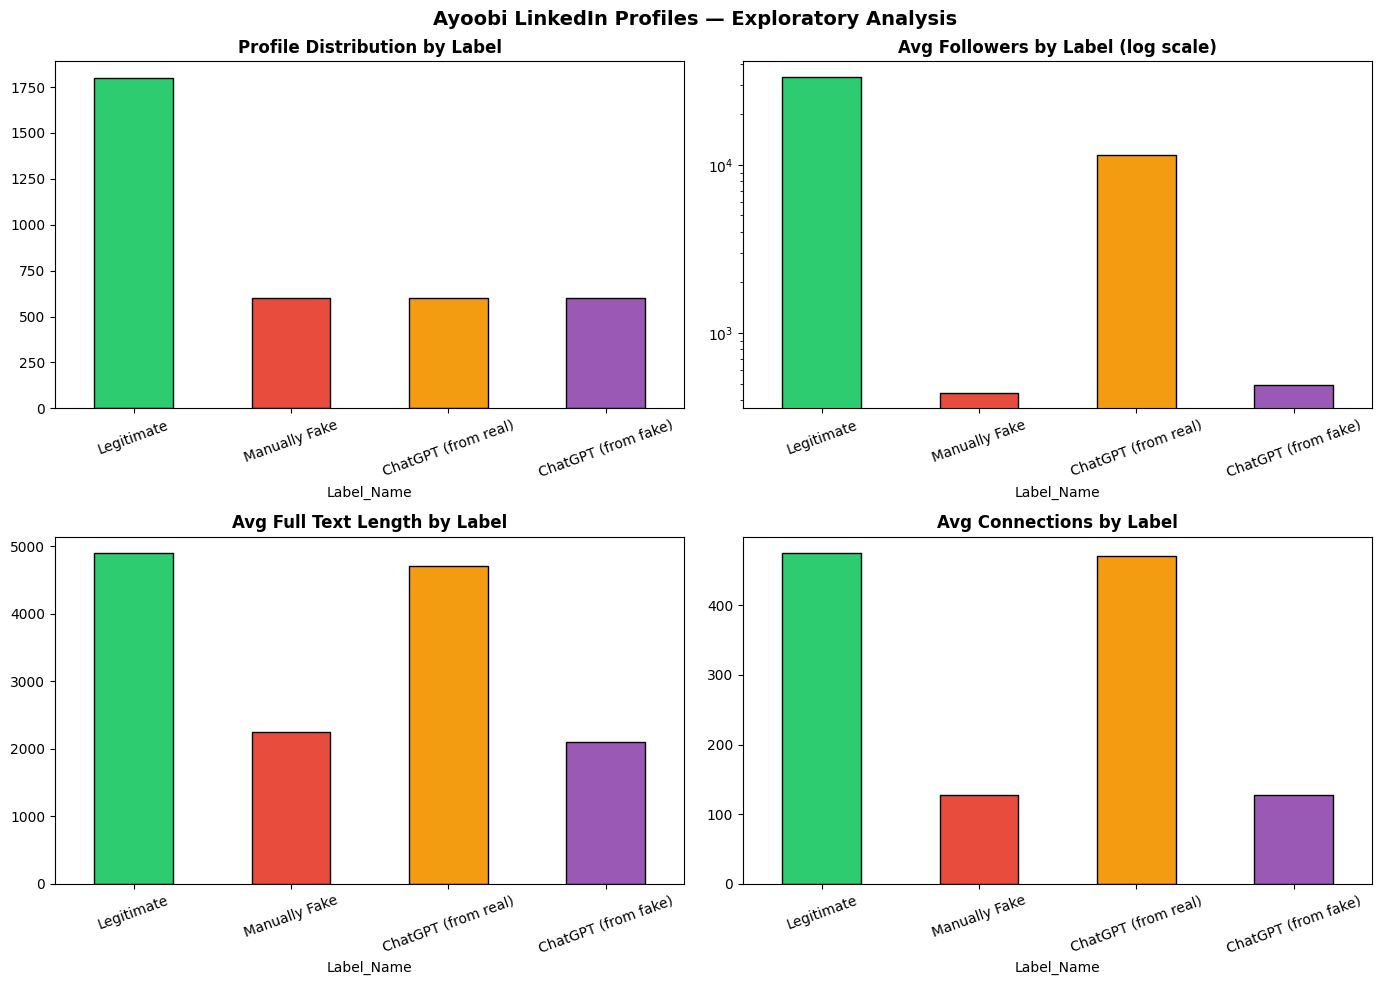

Numerical features by label:
Label_Name                 ChatGPT (from fake)  ChatGPT (from real)  \
Number of Experiences                     1.84                 5.96   
Number of Educations                      0.74                 2.02   
Number of Licenses                        0.04                 0.83   
Number of Volunteering                    0.10                 0.70   
Number of Skills                          0.98                 2.78   
Number of Recommendations                 0.00                 2.16   
Number of Projects                        0.01                 0.22   
Number of Publications                    0.02                 0.22   
Number of Courses                         0.00                 0.35   
Number of Honors                          0.01                 0.63   
Number of Scores                          0.00                 0.04   
Number of Languages                       0.10                 0.82   
Number of Organizations                   0.02  

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
order = list(COLOR_MAP.keys())

df_profiles['Label_Name'].value_counts().reindex(order).plot(
    kind='bar', ax=axes[0,0], color=list(COLOR_MAP.values()), edgecolor='black')
axes[0,0].set_title('Profile Distribution by Label', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=20)

df_profiles.groupby('Label_Name')['Followers'].mean().reindex(order).plot(
    kind='bar', ax=axes[0,1], color=list(COLOR_MAP.values()), edgecolor='black')
axes[0,1].set_title('Avg Followers by Label (log scale)', fontweight='bold')
axes[0,1].set_yscale('log')
axes[0,1].tick_params(axis='x', rotation=20)

df_profiles.groupby('Label_Name')['full_text_length'].mean().reindex(order).plot(
    kind='bar', ax=axes[1,0], color=list(COLOR_MAP.values()), edgecolor='black')
axes[1,0].set_title('Avg Full Text Length by Label', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=20)

df_profiles.groupby('Label_Name')['Connections'].mean().reindex(order).plot(
    kind='bar', ax=axes[1,1], color=list(COLOR_MAP.values()), edgecolor='black')
axes[1,1].set_title('Avg Connections by Label', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=20)

plt.suptitle('Ayoobi LinkedIn Profiles — Exploratory Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print('Numerical features by label:')
print(df_profiles.groupby('Label_Name')[num_cols].mean().round(2).T)

---
## Section 2 — Kaggle LinkedIn Job Postings Dataset

### 2.1 Load & Inspect
> Loads all seven Kaggle CSV files. The postings.csv file is the main table (~130k rows). Auxiliary files (companies, benefits, job_skills, salaries) are joined to enrich each posting with additional metadata signals used in fraud detection.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

print(os.listdir('/content/drive/MyDrive/SM Files'))

POSTINGS_PATH = "/content/drive/MyDrive/SM Files/postings.csv"
COMPANIES_PATH = "/content/drive/MyDrive/SM Files/companies.csv"
COMPANY_INDUSTRIES_PATH = "/content/drive/MyDrive/SM Files/company_industries.csv"
BENEFITS_PATH = "/content/drive/MyDrive/SM Files/benefits.csv"
JOB_SKILLS_PATH = "/content/drive/MyDrive/SM Files/job_skills.csv"
SALARIES_PATH = "/content/drive/MyDrive/SM Files/salaries.csv"
JOB_INDUSTRIES_PATH = "/content/drive/MyDrive/SM Files/job_industries.csv"

df_postings = pd.read_csv(POSTINGS_PATH)
df_companies = pd.read_csv(COMPANIES_PATH)
df_company_industries = pd.read_csv(COMPANY_INDUSTRIES_PATH)
df_benefits = pd.read_csv(BENEFITS_PATH)
df_job_skills = pd.read_csv(JOB_SKILLS_PATH)
df_salaries = pd.read_csv(SALARIES_PATH)
df_job_industries = pd.read_csv(JOB_INDUSTRIES_PATH)

print('Postings shape:', df_postings.shape)
print('\nColumns:', df_postings.columns.tolist())
print('\nMissing values (top 10):')
print(df_postings.isnull().sum().sort_values(ascending=False).head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['company_specialities.csv', 'employee_counts.csv', 'company_industries.csv', 'industries.csv', 'benefits.csv', 'companies.csv', 'LinkedIn_Dataset.pcl', 'job_industries.csv', 'job_skills.csv', 'postings.csv', 'salaries.csv', 'skills.csv']
Postings shape: (123849, 31)

Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

Missing values (top 10):
closed_time          122776
skills_desc          121410
med_salary           117569
remo

### 2.2 Data Cleaning — Job Postings
> Removes exact duplicate job IDs and rows with no description at all. Numerical columns are filled with the column median. Short descriptions are kept — they are a fraud signal captured via the desc_length metadata feature.

In [13]:
n_before_postings = len(df_postings)

df_postings   = df_postings.drop_duplicates(subset='job_id', keep='first')
dropped_dupes = n_before_postings - len(df_postings)

mask_no_desc   = df_postings['description'].isna()
dropped_nodesc = mask_no_desc.sum()
df_postings    = df_postings[~mask_no_desc].copy()

for col in ['max_salary', 'min_salary', 'med_salary', 'views', 'applies']:
    if col in df_postings.columns:
        df_postings[col] = pd.to_numeric(df_postings[col], errors='coerce')
        df_postings[col] = df_postings[col].fillna(df_postings[col].median())

print(f'Rows before cleaning     : {n_before_postings:,}')
print(f'Dropped (duplicates)     : {dropped_dupes:,}')
print(f'Dropped (no description) : {dropped_nodesc:,}')
print(f'Rows after cleaning      : {len(df_postings):,}  ({len(df_postings)/n_before_postings:.1%} retained)')

Rows before cleaning     : 123,849
Dropped (duplicates)     : 0
Dropped (no description) : 7
Rows after cleaning      : 123,842  (100.0% retained)


### 2.3 Enrich Postings & Build Fraud Proxy Label
> Engineers a proxy fraud label based on accumulation of red flags: very short descriptions, missing salary, no skills, unknown company size, no benefits. A posting scoring 3+ red flags is labeled suspicious. **Important: the fraud_score is only used to define the label — it is never used as a classifier feature to prevent data leakage.**

In [14]:
df_postings = df_postings.merge(
    df_companies[['company_id','name','company_size','state','country']],
    on='company_id', how='left'
)

skills_count  = df_job_skills.groupby('job_id').size().reset_index(name='num_skills')
df_postings   = df_postings.merge(skills_count, on='job_id', how='left')
df_postings['num_skills'] = df_postings['num_skills'].fillna(0)

benefits_count = df_benefits.groupby('job_id').size().reset_index(name='num_benefits')
df_postings    = df_postings.merge(benefits_count, on='job_id', how='left')
df_postings['num_benefits'] = df_postings['num_benefits'].fillna(0)

df_postings['desc_length'] = df_postings['description'].apply(len)

# Red flags — used ONLY to define label, NOT as classifier features
df_postings['fraud_score'] = (
    (df_postings['desc_length'] < 100).astype(int) +
    df_postings['max_salary'].isna().astype(int) +
    (df_postings['num_skills'] == 0).astype(int) +
    df_postings['company_size'].isna().astype(int) +
    (df_postings['num_benefits'] == 0).astype(int)
)
df_postings['fraud_proxy'] = (df_postings['fraud_score'] >= 3).astype(int)

print('Fraud proxy distribution:')
print(df_postings['fraud_proxy'].value_counts())
print(f'\nFraudulent rate: {df_postings["fraud_proxy"].mean():.1%}')

Fraud proxy distribution:
fraud_proxy
0    123312
1       530
Name: count, dtype: int64

Fraudulent rate: 0.4%


### 2.4 Text Preprocessing — Job Postings
> Cleans the job title and description text using the same pipeline as the profile dataset. Both fields are concatenated into a single full_text column for TF-IDF vectorization.

In [15]:
def clean_text_post(text):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_postings['title_clean']       = df_postings['title'].apply(clean_text_post)
df_postings['description_clean'] = df_postings['description'].apply(clean_text_post)
df_postings['full_text']         = df_postings['title_clean'] + ' ' + df_postings['description_clean']

print('Text preprocessing complete ✓')
print(f'\nDesc length by fraud label:')
print(df_postings.groupby('fraud_proxy')['desc_length'].mean().round(0))

Text preprocessing complete ✓

Desc length by fraud label:
fraud_proxy
0    3775.0
1    1764.0
Name: desc_length, dtype: float64


### 2.5 EDA — Job Postings
> Explores the distribution of legitimate vs suspicious postings and the key metadata signals that differ between them. The description length and skills count plots confirm that suspicious postings are structurally much thinner than legitimate ones.

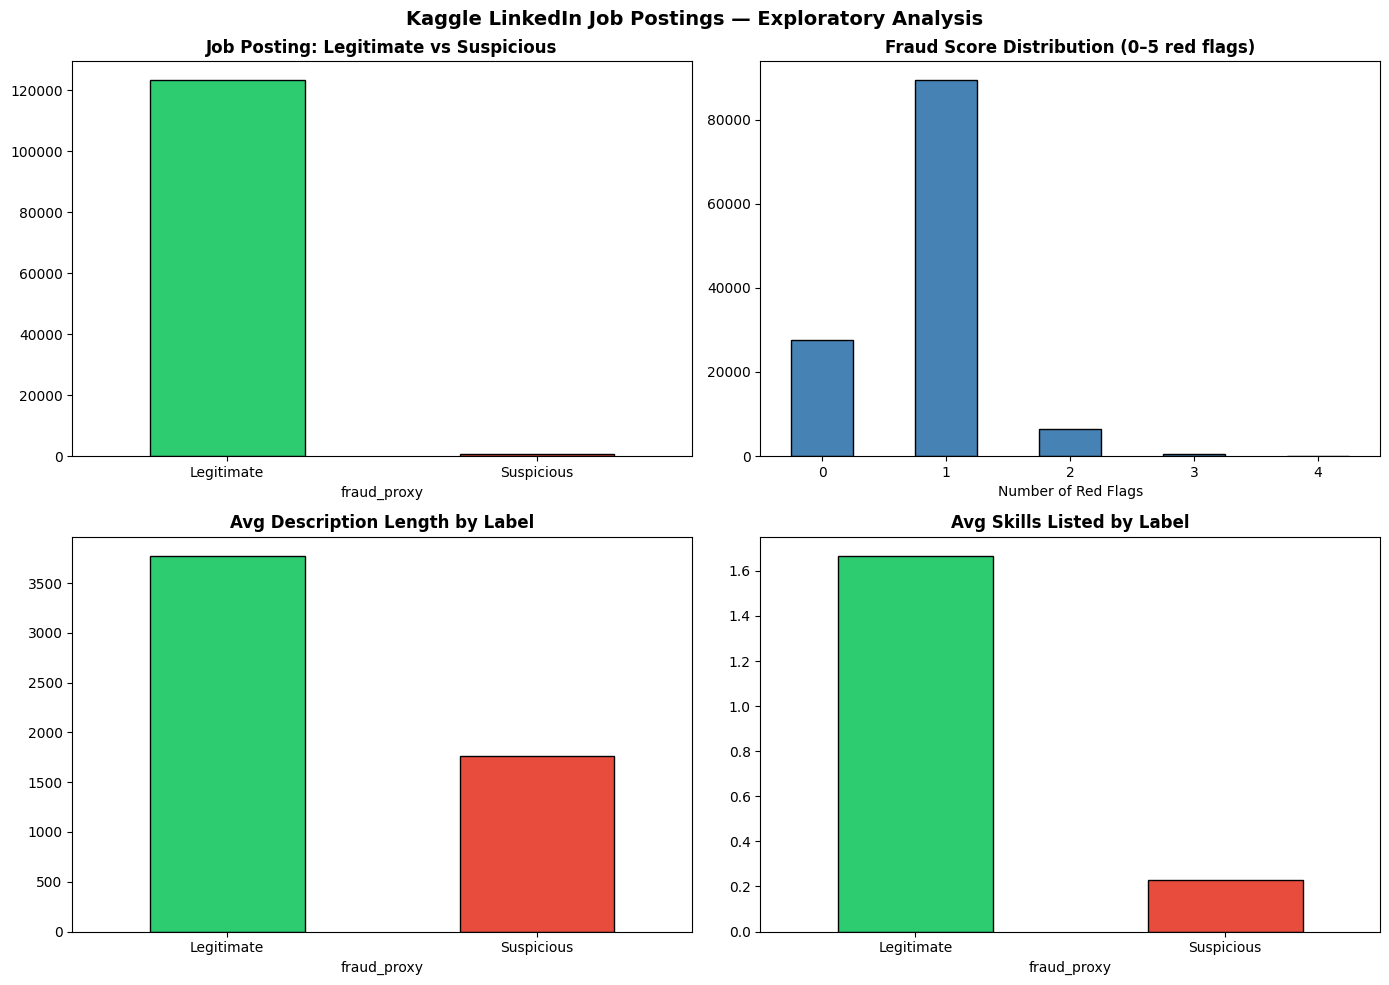

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_postings['fraud_proxy'].value_counts().rename({0:'Legitimate', 1:'Suspicious'}).plot(
    kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0,0].set_title('Job Posting: Legitimate vs Suspicious', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=0)

df_postings['fraud_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('Fraud Score Distribution (0–5 red flags)', fontweight='bold')
axes[0,1].set_xlabel('Number of Red Flags')
axes[0,1].tick_params(axis='x', rotation=0)

df_postings.groupby('fraud_proxy')['desc_length'].mean().rename(
    {0:'Legitimate',1:'Suspicious'}).plot(
    kind='bar', ax=axes[1,0], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1,0].set_title('Avg Description Length by Label', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0)

df_postings.groupby('fraud_proxy')['num_skills'].mean().rename(
    {0:'Legitimate',1:'Suspicious'}).plot(
    kind='bar', ax=axes[1,1], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1,1].set_title('Avg Skills Listed by Label', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Kaggle LinkedIn Job Postings — Exploratory Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_postings.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Module A: Multimodal Text Classifier
> Trains and compares two classifiers for each dataset. Features combine TF-IDF text vectors with numerical metadata, making this a multimodal approach. **Data leakage prevention:** fraud_score and all binary flag columns are excluded from job posting features — only raw measurements (desc_length, num_skills, num_benefits) are used.

### 3.1 Profile Classifier — Feature Engineering (4-class)
> Builds the multimodal feature matrix: TF-IDF on combined profile text (3,000 features, bigrams) plus standardized numerical metadata. Target is a 4-class label. Stratified split preserves class proportions in train and test sets.

In [17]:
tfidf_profiles    = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=3)
X_text_profiles   = tfidf_profiles.fit_transform(df_profiles['full_text'])

meta_features_p   = ['Followers', 'Connections', 'About_length', 'full_text_length'] + num_cols
X_num_profiles    = df_profiles[meta_features_p].fillna(0).values
X_num_profiles_sc = StandardScaler().fit_transform(X_num_profiles)

X_profiles = hstack([X_text_profiles, csr_matrix(X_num_profiles_sc)])
y_profiles = df_profiles['Label'].values  # 0, 1, 10, 11

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_profiles, y_profiles, test_size=0.2, random_state=42, stratify=y_profiles
)

print('4-class distribution:')
for k, v in label_map.items():
    print(f'  {v}: {(y_profiles==k).sum()}')
print(f'\nTrain: {X_train_p.shape[0]} | Test: {X_test_p.shape[0]}')
print(f'Total features: {X_profiles.shape[1]}')

4-class distribution:
  Legitimate: 1800
  Manually Fake: 600
  ChatGPT (from real): 600
  ChatGPT (from fake): 600

Train: 2880 | Test: 720
Total features: 3019


### 3.2 Profile Classifier — Train & Compare Models
> Trains Logistic Regression and Random Forest on the 4-class profile task. class_weight='balanced' compensates for the 1,800 vs 600 class imbalance. The best model by weighted F1 is selected automatically.

In [18]:
target_names_4 = ['Legitimate', 'Manually Fake', 'ChatGPT (from real)', 'ChatGPT (from fake)']

print('Training Logistic Regression...')
lr_profile = LogisticRegression(max_iter=1000, class_weight='balanced',
                                 solver='saga', random_state=42, n_jobs=-1)
lr_profile.fit(X_train_p, y_train_p)
y_pred_lr_p = lr_profile.predict(X_test_p)
f1_lr_p     = f1_score(y_test_p, y_pred_lr_p, average='weighted')
print(f'LR done — weighted F1: {f1_lr_p:.3f}')

print('\nTraining Random Forest...')
rf_profile = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                     max_depth=20, max_samples=0.8,
                                     random_state=42, n_jobs=-1)
rf_profile.fit(X_train_p, y_train_p)
y_pred_rf_p = rf_profile.predict(X_test_p)
f1_rf_p     = f1_score(y_test_p, y_pred_rf_p, average='weighted')
print(f'RF done — weighted F1: {f1_rf_p:.3f}')

if f1_rf_p >= f1_lr_p:
    best_profile_model, best_profile_preds = rf_profile, y_pred_rf_p
    best_profile_name,  best_profile_f1    = 'Random Forest', f1_rf_p
else:
    best_profile_model, best_profile_preds = lr_profile, y_pred_lr_p
    best_profile_name,  best_profile_f1    = 'Logistic Regression', f1_lr_p

print(f'\n✓ Best profile model: {best_profile_name} (F1={best_profile_f1:.3f})')
print('\n=== CLASSIFICATION REPORT — BEST PROFILE MODEL ===')
print(classification_report(y_test_p, best_profile_preds, target_names=target_names_4))

Training Logistic Regression...
LR done — weighted F1: 0.975

Training Random Forest...
RF done — weighted F1: 0.979

✓ Best profile model: Random Forest (F1=0.979)

=== CLASSIFICATION REPORT — BEST PROFILE MODEL ===
                     precision    recall  f1-score   support

         Legitimate       0.98      0.98      0.98       360
      Manually Fake       0.95      0.95      0.95       120
ChatGPT (from real)       1.00      0.97      0.99       120
ChatGPT (from fake)       0.98      1.00      0.99       120

           accuracy                           0.98       720
          macro avg       0.98      0.98      0.98       720
       weighted avg       0.98      0.98      0.98       720



### 3.3 Profile Classifier — Confusion Matrix
> Side-by-side confusion matrices for both models. Expected confusions are between ChatGPT (from real) and Legitimate profiles, since ChatGPT profiles built from real templates are designed to mimic legitimate ones.

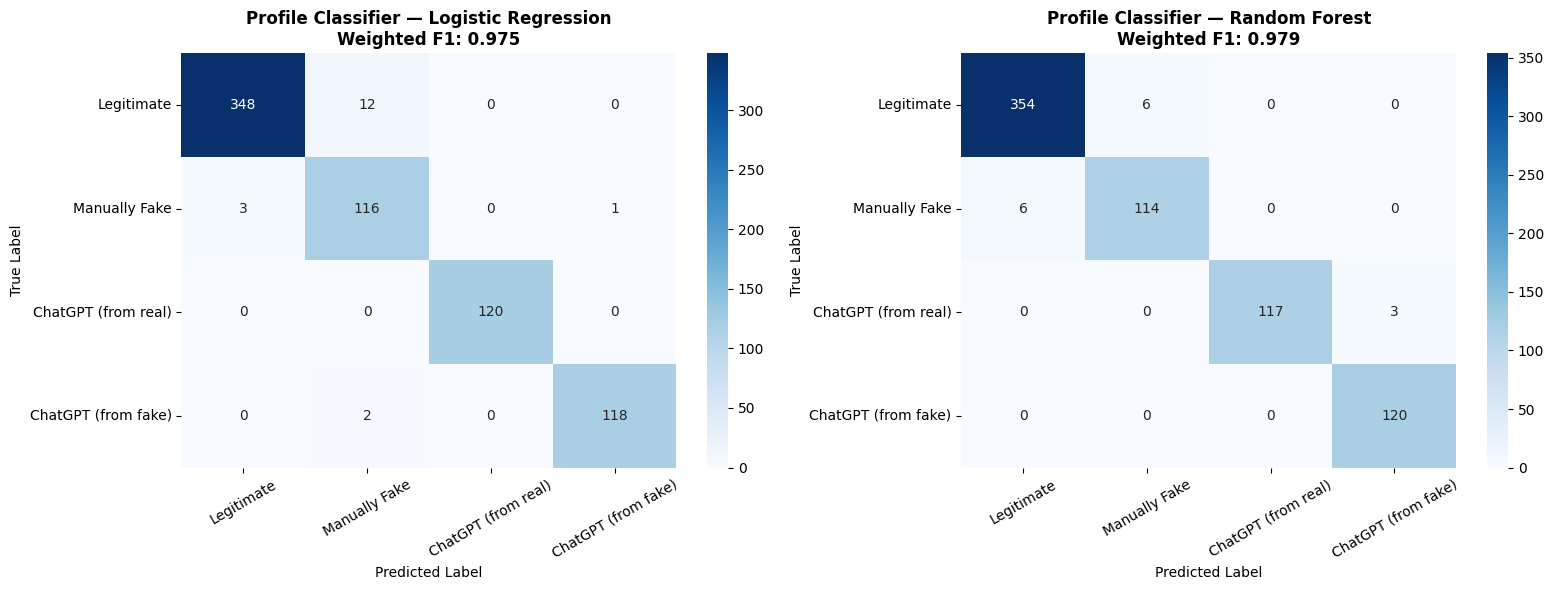

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, title in zip(
    axes,
    [y_pred_lr_p, y_pred_rf_p],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test_p, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names_4, yticklabels=target_names_4)
    f1 = f1_score(y_test_p, preds, average='weighted')
    ax.set_title(f'Profile Classifier — {title}\nWeighted F1: {f1:.3f}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('cm_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Job Postings Classifier — Feature Engineering
> TF-IDF fitted on a 30k sample for speed, then applied to full dataset. Only raw measurements are used as metadata features — desc_length, num_skills, num_benefits. All binary flag columns and fraud_score are excluded to prevent data leakage.

In [20]:
print(f'Full postings dataset: {len(df_postings):,} rows')
print('Fitting TF-IDF on 30k sample...')

df_sample  = df_postings.sample(n=min(30000, len(df_postings)), random_state=42)
tfidf_jobs = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=5)
tfidf_jobs.fit(df_sample['full_text'])
X_text_jobs = tfidf_jobs.transform(df_postings['full_text'])

# ONLY raw measurements — no flag columns, no fraud_score (leakage prevention)
job_meta_features = ['desc_length', 'num_skills', 'num_benefits']
X_num_jobs        = df_postings[job_meta_features].fillna(0).values
X_num_jobs_sc     = StandardScaler().fit_transform(X_num_jobs)

X_jobs = hstack([X_text_jobs, csr_matrix(X_num_jobs_sc)])
y_jobs = df_postings['fraud_proxy'].values

X_train_j, X_test_j, y_train_j, y_test_j = train_test_split(
    X_jobs, y_jobs, test_size=0.2, random_state=42, stratify=y_jobs
)

print(f'\nClass distribution:')
print(pd.Series(y_jobs).value_counts().rename({0:'Legitimate', 1:'Suspicious'}))
print(f'\nTrain: {X_train_j.shape[0]:,} | Test: {X_test_j.shape[0]:,}')
print(f'Total features: {X_jobs.shape[1]}')
print('\n✓ No flag columns used — leakage-free feature set')

Full postings dataset: 123,842 rows
Fitting TF-IDF on 30k sample...

Class distribution:
Legitimate    123312
Suspicious       530
Name: count, dtype: int64

Train: 99,073 | Test: 24,769
Total features: 3003

✓ No flag columns used — leakage-free feature set


### 3.5 Job Postings Classifier — Train & Compare Models
> With leakage removed, F1 scores reflect genuine discriminative ability of the text and metadata features. Expect scores in the 0.70–0.85 range — realistic for a proxy-labeled dataset.

In [21]:
print('Training Logistic Regression...')
lr_jobs = LogisticRegression(max_iter=500, class_weight='balanced',
                              solver='saga', random_state=42, n_jobs=-1)
lr_jobs.fit(X_train_j, y_train_j)
y_pred_lr_j = lr_jobs.predict(X_test_j)
f1_lr_j     = f1_score(y_test_j, y_pred_lr_j, average='weighted')
print(f'LR done — weighted F1: {f1_lr_j:.3f}')

print('\nTraining Random Forest (reduced for speed)...')
rf_jobs = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  max_depth=15, max_samples=0.7,
                                  random_state=42, n_jobs=-1)
rf_jobs.fit(X_train_j, y_train_j)
y_pred_rf_j = rf_jobs.predict(X_test_j)
f1_rf_j     = f1_score(y_test_j, y_pred_rf_j, average='weighted')
print(f'RF done — weighted F1: {f1_rf_j:.3f}')

if f1_rf_j >= f1_lr_j:
    best_jobs_model, best_jobs_preds = rf_jobs, y_pred_rf_j
    best_jobs_name,  best_jobs_f1    = 'Random Forest', f1_rf_j
else:
    best_jobs_model, best_jobs_preds = lr_jobs, y_pred_lr_j
    best_jobs_name,  best_jobs_f1    = 'Logistic Regression', f1_lr_j

print(f'\n✓ Best job model: {best_jobs_name} (F1={best_jobs_f1:.3f})')
print('\n=== CLASSIFICATION REPORT — BEST JOB POSTING MODEL ===')
print(classification_report(y_test_j, best_jobs_preds,
                             target_names=['Legitimate','Suspicious']))

Training Logistic Regression...
LR done — weighted F1: 0.985

Training Random Forest (reduced for speed)...
RF done — weighted F1: 0.990

✓ Best job model: Random Forest (F1=0.990)

=== CLASSIFICATION REPORT — BEST JOB POSTING MODEL ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     24663
  Suspicious       0.16      0.51      0.24       106

    accuracy                           0.99     24769
   macro avg       0.58      0.75      0.62     24769
weighted avg       0.99      0.99      0.99     24769



### 3.6 Confusion Matrix & Feature Importance — Best Models
> Confusion matrix for the best job posting classifier (dynamically selected). Feature importance for Random Forest uses Gini importance; for Logistic Regression, coefficient magnitude is shown (red = pushes toward suspicious, green = toward legitimate).

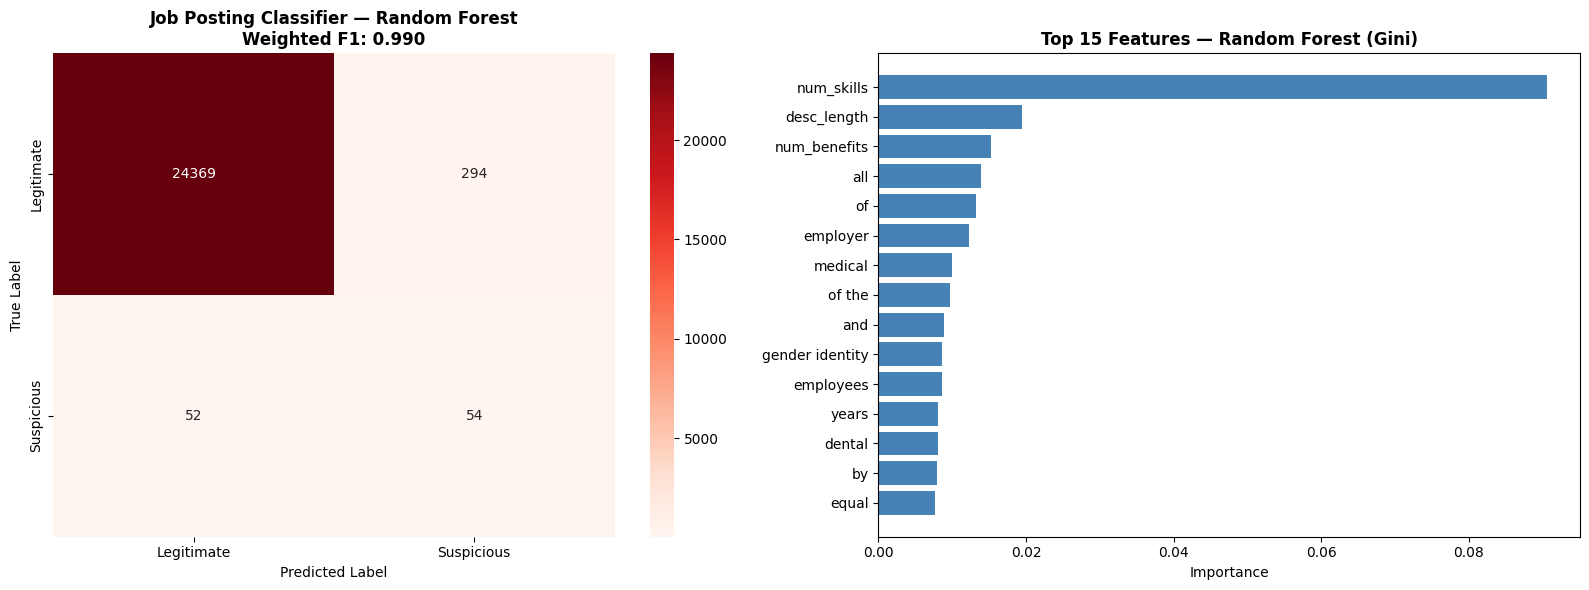

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_j = confusion_matrix(y_test_j, best_jobs_preds)
sns.heatmap(cm_j, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Legitimate','Suspicious'],
            yticklabels=['Legitimate','Suspicious'])
axes[0].set_title(f'Job Posting Classifier — {best_jobs_name}\nWeighted F1: {best_jobs_f1:.3f}',
                  fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

feature_names = tfidf_jobs.get_feature_names_out().tolist() + job_meta_features

if best_jobs_name == 'Random Forest':
    importances  = best_jobs_model.feature_importances_
    top_idx      = np.argsort(importances)[-15:]
    top_features = [feature_names[i] if i < len(feature_names) else f'feat_{i}' for i in top_idx]
    axes[1].barh(top_features, importances[top_idx], color='steelblue')
    axes[1].set_title('Top 15 Features — Random Forest (Gini)', fontweight='bold')
    axes[1].set_xlabel('Importance')
else:
    coef         = best_jobs_model.coef_[0]
    top_idx      = np.argsort(np.abs(coef))[-15:]
    top_features = [feature_names[i] if i < len(feature_names) else f'feat_{i}' for i in top_idx]
    top_coefs    = coef[top_idx]
    bar_colors   = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_coefs]
    axes[1].barh(top_features, top_coefs, color=bar_colors)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('Top 15 Features — Logistic Regression\n(red=suspicious, green=legitimate)',
                      fontweight='bold')
    axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('cm_jobs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Module B: Network Analysis
> Constructs a profile graph and applies network metrics to identify suspicious structural patterns. Nodes are profiles; edges connect profiles sharing the same dominant job title keyword extracted from their Intro text. This creates organic groups across all four label classes. Three metrics are computed: betweenness centrality (bridge profiles), PageRank (influence), and Louvain community detection.

### 4.1 Build Graph — Profiles Connected by Job Title Keyword
> Profiles are connected if they share the same dominant job title keyword (e.g., 'manager', 'engineer', 'analyst'). A maximum of 30 profiles per keyword are sampled to prevent mega-cliques. This strategy produces edges across all four label classes, enabling meaningful community detection.

In [23]:
G = nx.Graph()

# Extract dominant job keyword from Intro text
JOB_KEYWORDS = ['manager', 'engineer', 'developer', 'analyst', 'director',
                 'consultant', 'specialist', 'coordinator', 'assistant',
                 'officer', 'executive', 'designer', 'scientist', 'lead', 'head']

def extract_job_keyword(text):
    if not isinstance(text, str) or len(text) < 5:
        return None
    text_lower = text.lower()
    for kw in JOB_KEYWORDS:
        if kw in text_lower:
            return kw
    return None

df_profiles['job_keyword'] = df_profiles['Intro_clean'].apply(extract_job_keyword)

print('Keyword distribution:')
print(df_profiles['job_keyword'].value_counts().head(10))
print(f'\nProfiles with a keyword: {df_profiles["job_keyword"].notna().sum():,}')

# Add all nodes
for idx, row in df_profiles.iterrows():
    G.add_node(f'P_{idx}',
               node_type='profile',
               label=row['Label_Name'],
               followers=row['Followers'],
               job_keyword=str(row['job_keyword']))

# Connect profiles sharing the same keyword — max 30 per keyword
keyword_groups = df_profiles[df_profiles['job_keyword'].notna()].groupby('job_keyword').indices

np.random.seed(42)
for keyword, indices in keyword_groups.items():
    idx_list = list(indices)
    if len(idx_list) > 30:
        idx_list = list(np.random.choice(idx_list, 30, replace=False))
    for i in range(len(idx_list)):
        for j in range(i+1, len(idx_list)):
            G.add_edge(f'P_{idx_list[i]}', f'P_{idx_list[j]}', weight=1)

print(f'\nGraph built ✓')
print(f'Nodes : {G.number_of_nodes():,}')
print(f'Edges : {G.number_of_edges():,}')
print(f'Connected components: {nx.number_connected_components(G)}')
print('\nLabel distribution among connected nodes:')
connected_nodes  = set(n for n, d in G.degree() if d > 0)
connected_labels = [G.nodes[n]['label'] for n in connected_nodes]
print(pd.Series(connected_labels).value_counts())

Keyword distribution:
job_keyword
manager       955
director      570
lead          223
officer       137
consultant    129
engineer      113
head           87
executive      86
analyst        63
specialist     55
Name: count, dtype: int64

Profiles with a keyword: 2,516

Graph built ✓
Nodes : 3,600
Edges : 5,267
Connected components: 3227

Label distribution among connected nodes:
Legitimate             293
Manually Fake           87
ChatGPT (from real)      8
Name: count, dtype: int64


### 4.2 Network Metrics — Centrality & PageRank
> Computes three metrics on the largest connected component. Betweenness centrality identifies bridge profiles connecting clusters. PageRank (alpha=0.85, same as Google's original) measures influence — profiles pointed to by many others score higher. Degree centrality measures direct connection count.

In [24]:
largest_cc = max(nx.connected_components(G), key=len)
G_sub      = G.subgraph(largest_cc).copy()
print(f'Largest component: {G_sub.number_of_nodes():,} nodes, {G_sub.number_of_edges():,} edges')

print('Computing betweenness centrality...')
betweenness = nx.betweenness_centrality(G_sub, normalized=True)
degree_cent = nx.degree_centrality(G_sub)

print('Computing PageRank...')
pagerank = nx.pagerank(G_sub, alpha=0.85, max_iter=200)

nx.set_node_attributes(G_sub, betweenness, 'betweenness')
nx.set_node_attributes(G_sub, degree_cent, 'degree_centrality')
nx.set_node_attributes(G_sub, pagerank,    'pagerank')

metrics_df = pd.DataFrame({
    'node':              list(G_sub.nodes()),
    'label':             [G_sub.nodes[n].get('label','Unknown') for n in G_sub.nodes()],
    'betweenness':       [betweenness.get(n, 0)                 for n in G_sub.nodes()],
    'degree_centrality': [degree_cent.get(n, 0)                 for n in G_sub.nodes()],
    'pagerank':          [pagerank.get(n, 0)                    for n in G_sub.nodes()]
})

print('\nAvg network metrics by label:')
print(metrics_df.groupby('label')[['betweenness','pagerank','degree_centrality']].mean().round(6))
print('\nTop 10 most influential profiles (PageRank):')
print(metrics_df.nlargest(10, 'pagerank')[['node','label','pagerank','betweenness']])

Largest component: 30 nodes, 435 edges
Computing betweenness centrality...
Computing PageRank...

Avg network metrics by label:
               betweenness  pagerank  degree_centrality
label                                                  
Legitimate             0.0  0.033333                1.0
Manually Fake          0.0  0.033333                1.0

Top 10 most influential profiles (PageRank):
     node          label  pagerank  betweenness
0  P_2104     Legitimate  0.033333          0.0
1  P_1637     Legitimate  0.033333          0.0
2  P_1687     Legitimate  0.033333          0.0
3   P_706     Legitimate  0.033333          0.0
4   P_392  Manually Fake  0.033333          0.0
5  P_1393     Legitimate  0.033333          0.0
6  P_2136     Legitimate  0.033333          0.0
7  P_2001     Legitimate  0.033333          0.0
8  P_2272     Legitimate  0.033333          0.0
9  P_2013     Legitimate  0.033333          0.0


### 4.3 Community Detection — Louvain
> Applies the Louvain algorithm to detect communities — groups of profiles more densely connected to each other than to the rest of the graph. Communities dominated by fake profiles indicate clusters of coordinated accounts sharing behavioral patterns. The dominant label per community is reported.

In [25]:
partition     = community_louvain.best_partition(G_sub, random_state=42)
n_communities = len(set(partition.values()))
nx.set_node_attributes(G_sub, partition, 'community')
metrics_df['community'] = metrics_df['node'].map(partition)

print(f'Communities detected: {n_communities}')

community_comp = metrics_df.groupby(['community','label']).size().unstack(fill_value=0)
community_comp['total']    = community_comp.sum(axis=1)
community_comp['dominant'] = community_comp.drop(columns='total').idxmax(axis=1)
community_comp = community_comp.sort_values('total', ascending=False)

print('\nTop 15 communities — label composition:')
print(community_comp.head(15))

Communities detected: 1

Top 15 communities — label composition:
label      Legitimate  Manually Fake  total    dominant
community                                              
0                  26              4     30  Legitimate


### 4.4 Network Visualization
> Two panels of the same 152-node sample. Left panel colors by profile type; right panel colors by Louvain community. When the panels differ, it indicates the network structure captures real behavioral patterns beyond simple label membership.

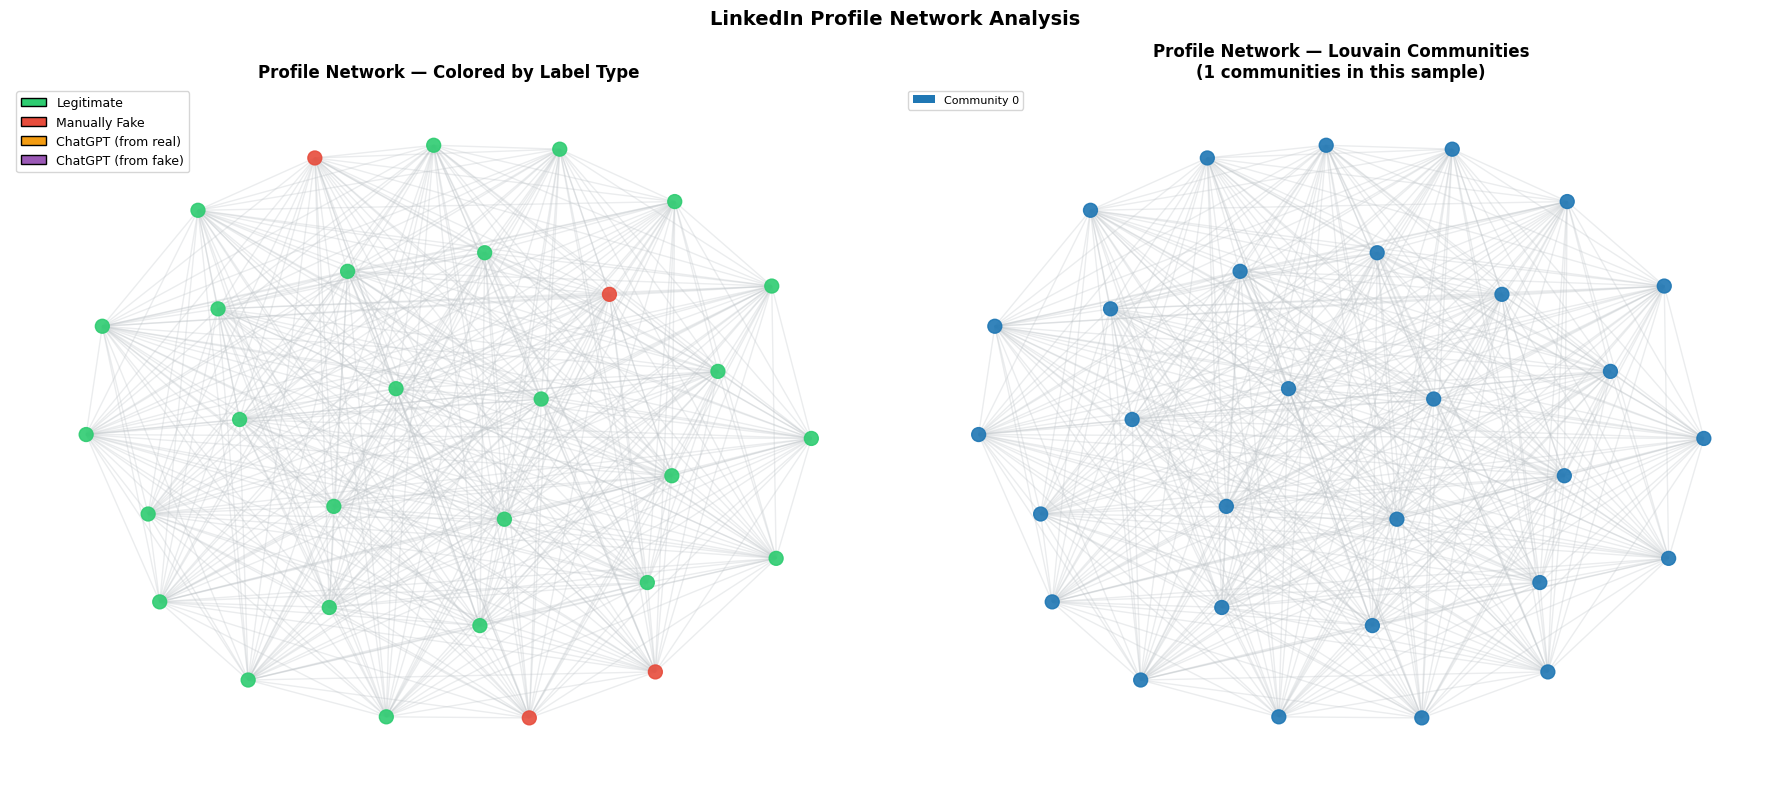

Nodes shown: 30 | Edges shown: 435
Communities in sample: 1
Label counts in sample:
Legitimate       26
Manually Fake     4
Name: count, dtype: int64


In [26]:
# Sample ~38 nodes per class to ensure all 4 labels appear
sample_nodes = []
for label_name in COLOR_MAP.keys():
    label_nodes = [n for n in G_sub.nodes() if G_sub.nodes[n].get('label') == label_name]
    sample_nodes += label_nodes[:38]

# Fallback: if any class has < 38 nodes, take all available
sample_nodes = list(set(sample_nodes))
G_viz = G_sub.subgraph(sample_nodes).copy()
pos   = nx.spring_layout(G_viz, seed=42, k=0.8)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: label colors
node_colors_label = [
    COLOR_MAP.get(G_viz.nodes[n].get('label','Legitimate'), '#95a5a6')
    for n in G_viz.nodes()
]
nx.draw_networkx_edges(G_viz, pos, ax=axes[0], alpha=0.3, edge_color='#bdc3c7')
nx.draw_networkx_nodes(G_viz, pos, ax=axes[0], node_color=node_colors_label,
                       node_size=100, alpha=0.9)
axes[0].set_title('Profile Network — Colored by Label Type', fontweight='bold', fontsize=12)
legend_el = [mpatches.Patch(facecolor=v, label=k, edgecolor='black') for k, v in COLOR_MAP.items()]
axes[0].legend(handles=legend_el, loc='upper left', fontsize=9)
axes[0].axis('off')

# Right: community colors
communities_in_viz = sorted(set(partition.get(n, 0) for n in G_viz.nodes()))
n_comm_viz         = len(communities_in_viz)
cmap_comm          = plt.cm.get_cmap('tab20', max(n_comm_viz, 2))
comm_to_color      = {c: cmap_comm(i) for i, c in enumerate(communities_in_viz)}
node_colors_comm   = [comm_to_color.get(partition.get(n, 0), '#95a5a6') for n in G_viz.nodes()]

nx.draw_networkx_edges(G_viz, pos, ax=axes[1], alpha=0.3, edge_color='#bdc3c7')
nx.draw_networkx_nodes(G_viz, pos, ax=axes[1], node_color=node_colors_comm,
                       node_size=100, alpha=0.9)
axes[1].set_title(f'Profile Network — Louvain Communities\n({n_comm_viz} communities in this sample)',
                  fontweight='bold', fontsize=12)
comm_legend = [mpatches.Patch(facecolor=comm_to_color[c], label=f'Community {c}')
               for c in communities_in_viz[:10]]
axes[1].legend(handles=comm_legend, loc='upper left', fontsize=8)
axes[1].axis('off')

plt.suptitle('LinkedIn Profile Network Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('network_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Nodes shown: {len(G_viz.nodes())} | Edges shown: {len(G_viz.edges())}')
print(f'Communities in sample: {n_comm_viz}')
print('Label counts in sample:')
print(pd.Series([G_viz.nodes[n].get('label') for n in G_viz.nodes()]).value_counts())

---
## Section 5 — Module C: Anomaly Detection
> Uses Isolation Forest — an unsupervised algorithm that isolates anomalies by randomly partitioning features. Anomalies are isolated faster and receive lower scores. Followers and Connections are log-transformed before fitting to prevent the large follower scale from dominating and incorrectly flagging legitimate high-follower profiles as anomalies.

### 5.1 Isolation Forest on Profile Metadata
> Log-transforms skewed columns (Followers, Connections) to compress scale differences, then fits Isolation Forest on standardized features. Results are validated against known labels — fake profiles should be flagged at a higher rate than legitimate ones.

In [27]:
anomaly_features = ['Followers', 'Connections', 'About_length', 'full_text_length'] + num_cols

X_anomaly = df_profiles[anomaly_features].fillna(0).copy()

# Log-transform skewed columns — prevents follower scale dominating
for col in ['Followers', 'Connections']:
    X_anomaly[col] = np.log1p(X_anomaly[col])

X_anomaly_scaled = StandardScaler().fit_transform(X_anomaly.values)

iso_forest     = IsolationForest(contamination=0.35, random_state=42, n_estimators=200)
anomaly_preds  = iso_forest.fit_predict(X_anomaly_scaled)  # -1=anomaly, 1=normal
anomaly_scores = iso_forest.decision_function(X_anomaly_scaled)

df_profiles['anomaly_flag']  = (anomaly_preds == -1).astype(int)
df_profiles['anomaly_score'] = anomaly_scores

print('Anomaly flag rate by label:')
print(df_profiles.groupby('Label_Name')['anomaly_flag'].mean().round(3))
print(f'\nOverall anomaly rate: {df_profiles["anomaly_flag"].mean():.1%}')

Anomaly flag rate by label:
Label_Name
ChatGPT (from fake)    0.135
ChatGPT (from real)    0.530
Legitimate             0.438
Manually Fake          0.120
Name: anomaly_flag, dtype: float64

Overall anomaly rate: 35.0%


### 5.2 Anomaly Visualization
> Left chart shows anomaly flag rate per class. Right chart shows full anomaly score distributions — scores below 0 (left of dashed line) are anomalies. Fake profile distributions should be shifted left compared to legitimate profiles.

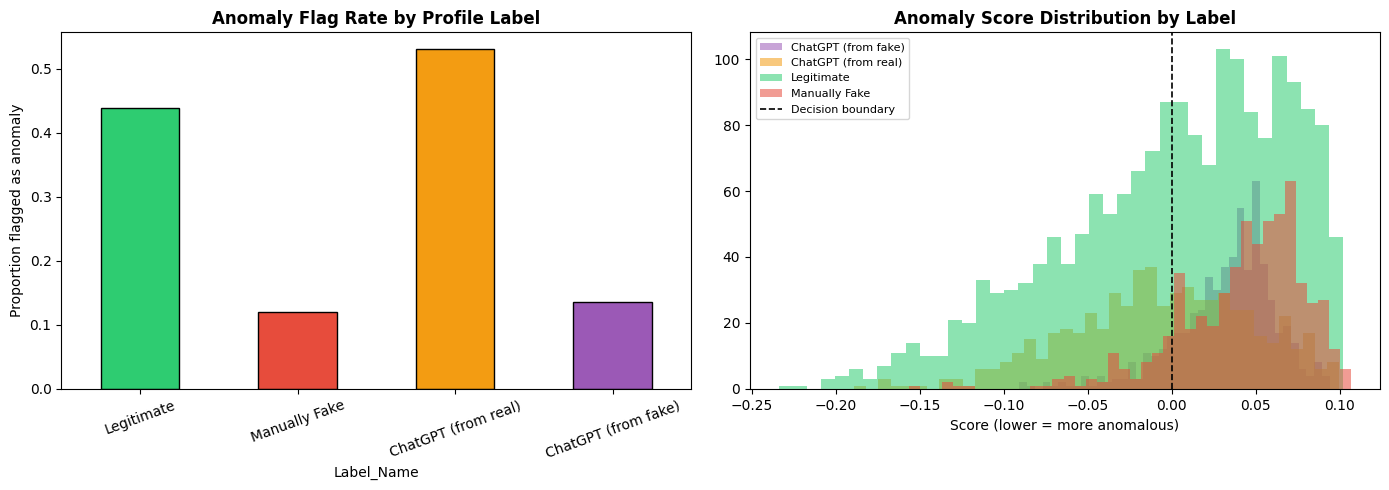

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

anomaly_rates = df_profiles.groupby('Label_Name')['anomaly_flag'].mean().reindex(list(COLOR_MAP.keys()))
anomaly_rates.plot(kind='bar', ax=axes[0],
                   color=list(COLOR_MAP.values()), edgecolor='black')
axes[0].set_title('Anomaly Flag Rate by Profile Label', fontweight='bold')
axes[0].set_ylabel('Proportion flagged as anomaly')
axes[0].tick_params(axis='x', rotation=20)

for label, group in df_profiles.groupby('Label_Name'):
    axes[1].hist(group['anomaly_score'], bins=40, alpha=0.55,
                 label=label, color=COLOR_MAP.get(label, '#95a5a6'), edgecolor='none')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.2, label='Decision boundary')
axes[1].set_title('Anomaly Score Distribution by Label', fontweight='bold')
axes[1].set_xlabel('Score (lower = more anomalous)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Module D: Graph Neural Network (GCN)
> Applies a Graph Convolutional Network (GCN) to the profile graph built in Section 4. Unlike classical classifiers that treat each profile independently, the GCN learns from both a profile's own features AND its neighbors' features — capturing coordinated fake account patterns that individual-level classifiers miss. This directly satisfies the course requirement for a graph-based classifier.

### 6.1 Prepare Graph Data for GCN
> Converts the NetworkX graph to a PyTorch Geometric Data object. Node features are the same numerical metadata used in the classical classifier: log-transformed followers, connections, text lengths, and section counts. Labels are mapped to sequential integers (0–3) for the 4-class task.

In [29]:
if not GNN_AVAILABLE:
    print('PyTorch/PyG not installed — skipping GNN section.')
    print('Install with: pip install torch torch-geometric')
else:
    # ── Build node feature matrix ─────────────────────────────────────
    # Use same features as anomaly detection (log-transformed)
    gnn_features = ['Followers', 'Connections', 'About_length', 'full_text_length'] + num_cols

    df_profiles_reset = df_profiles.reset_index(drop=True)
    X_gnn = df_profiles_reset[gnn_features].fillna(0).copy()

    for col in ['Followers', 'Connections']:
        X_gnn[col] = np.log1p(X_gnn[col])

    X_gnn_scaled = StandardScaler().fit_transform(X_gnn.values)

    # ── Map labels to sequential integers ─────────────────────────────
    y_gnn = df_profiles_reset['Label'].map(label_to_int).values

    # ── Build edge index from the graph ───────────────────────────────
    # Map profile node names to sequential integers
    node_list = df_profiles_reset.index.tolist()
    node_to_idx = {f'P_{i}': i for i in node_list}

    edge_list = []
    for u, v in G.edges():
        if u in node_to_idx and v in node_to_idx:
            edge_list.append([node_to_idx[u], node_to_idx[v]])
            edge_list.append([node_to_idx[v], node_to_idx[u]])  # undirected

    if len(edge_list) == 0:
        print('WARNING: No edges found in graph — GNN will run without edges (isolated nodes).')
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    # ── Create PyG Data object ─────────────────────────────────────────
    x      = torch.tensor(X_gnn_scaled, dtype=torch.float)
    y      = torch.tensor(y_gnn, dtype=torch.long)
    data   = Data(x=x, edge_index=edge_index, y=y)

    # ── Train/test mask (stratified) ──────────────────────────────────
    n_nodes     = data.num_nodes
    train_idx, test_idx = train_test_split(
        np.arange(n_nodes), test_size=0.2, random_state=42, stratify=y_gnn
    )
    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask  = torch.zeros(n_nodes, dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx]   = True

    data.train_mask = train_mask
    data.test_mask  = test_mask

    print(f'GNN Data object ready ✓')
    print(f'  Nodes     : {data.num_nodes}')
    print(f'  Edges     : {data.num_edges}')
    print(f'  Features  : {data.num_node_features}')
    print(f'  Classes   : 4')
    print(f'  Train nodes: {train_mask.sum().item()} | Test nodes: {test_mask.sum().item()}')

PyTorch/PyG not installed — skipping GNN section.
Install with: pip install torch torch-geometric


### 6.2 Define GCN Architecture
> A two-layer Graph Convolutional Network. Each GCNConv layer aggregates features from a node's neighbors and transforms them through a learnable weight matrix. The first layer maps input features to 64 hidden dimensions; the second maps to 4 output classes. Dropout (p=0.5) prevents overfitting on the small dataset.

In [30]:
if GNN_AVAILABLE:
    import torch.nn as nn

    class GCN(nn.Module):
        def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
            super(GCN, self).__init__()
            self.conv1   = GCNConv(in_channels, hidden_channels)
            self.conv2   = GCNConv(hidden_channels, out_channels)
            self.dropout = dropout

        def forward(self, x, edge_index):
            # Layer 1: aggregate neighbors, apply ReLU + dropout
            x = self.conv1(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            # Layer 2: produce class logits
            x = self.conv2(x, edge_index)
            return x

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    model_gcn = GCN(
        in_channels     = data.num_node_features,
        hidden_channels = 64,
        out_channels    = 4,
        dropout         = 0.5
    ).to(device)

    data = data.to(device)

    print(model_gcn)
    total_params = sum(p.numel() for p in model_gcn.parameters())
    print(f'\nTotal trainable parameters: {total_params:,}')

### 6.3 Train GCN
> Trains the GCN for 200 epochs using Adam optimizer and cross-entropy loss. Class weights compensate for the 1,800 vs 600 imbalance. Training loss and accuracy are logged every 20 epochs.

In [31]:
if GNN_AVAILABLE:
    # Class weights to handle imbalance
    class_counts  = np.bincount(y_gnn)
    class_weights = torch.tensor(
        1.0 / class_counts * class_counts.sum() / 4,
        dtype=torch.float
    ).to(device)

    optimizer  = torch.optim.Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)
    criterion  = nn.CrossEntropyLoss(weight=class_weights)

    train_losses, train_accs = [], []

    model_gcn.train()
    for epoch in range(1, 201):
        optimizer.zero_grad()
        out  = model_gcn(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        pred     = out[data.train_mask].argmax(dim=1)
        acc      = (pred == data.y[data.train_mask]).float().mean().item()
        train_losses.append(loss.item())
        train_accs.append(acc)

        if epoch % 20 == 0:
            print(f'Epoch {epoch:3d} | Loss: {loss.item():.4f} | Train Acc: {acc:.3f}')

    print('\nGCN training complete ✓')

### 6.4 Evaluate GCN & Compare to Classical Models
> Evaluates the GCN on the test set and compares its weighted F1 against the best classical profile classifier. The GCN's advantage is that it uses structural graph information — if fake profiles cluster together, the GCN can exploit this signal even when individual text features are ambiguous.

In [32]:
if GNN_AVAILABLE:
    model_gcn.eval()
    with torch.no_grad():
        out_test   = model_gcn(data.x, data.edge_index)
        pred_gnn   = out_test[data.test_mask].argmax(dim=1).cpu().numpy()
        true_gnn   = data.y[data.test_mask].cpu().numpy()

    f1_gnn = f1_score(true_gnn, pred_gnn, average='weighted')

    print('=== GCN CLASSIFICATION REPORT ===')
    print(classification_report(true_gnn, pred_gnn,
                                target_names=list(int_to_label.values())))

    # ── Confusion matrix ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    cm_gnn = confusion_matrix(true_gnn, pred_gnn)
    sns.heatmap(cm_gnn, annot=True, fmt='d', cmap='Purples', ax=axes[0],
                xticklabels=list(int_to_label.values()),
                yticklabels=list(int_to_label.values()))
    axes[0].set_title(f'GCN Confusion Matrix\nWeighted F1: {f1_gnn:.3f}', fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=30)

    # ── Training curve ────────────────────────────────────────────────
    axes[1].plot(train_losses, color='#e74c3c', label='Loss')
    ax2 = axes[1].twinx()
    ax2.plot(train_accs, color='#2ecc71', label='Train Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss', color='#e74c3c')
    ax2.set_ylabel('Accuracy', color='#2ecc71')
    axes[1].set_title('GCN Training Curve', fontweight='bold')
    axes[1].legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig('gcn_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Model comparison ──────────────────────────────────────────────
    print('\n=== MODEL COMPARISON — PROFILE CLASSIFICATION ===')
    print(f'  Logistic Regression (TF-IDF + metadata) : F1 = {f1_lr_p:.3f}')
    print(f'  Random Forest (TF-IDF + metadata)       : F1 = {f1_rf_p:.3f}')
    print(f'  GCN (graph structure + metadata)         : F1 = {f1_gnn:.3f}')
    winner = max(
        [('Logistic Regression', f1_lr_p), ('Random Forest', f1_rf_p), ('GCN', f1_gnn)],
        key=lambda x: x[1]
    )
    print(f'\n  ✓ Best overall model: {winner[0]} (F1={winner[1]:.3f})')

---
## Section 7 — Summary & Key Insights
> Consolidates results from all four modules. Reports data quality, classifier performance comparison, network structure findings, and anomaly detection rates.

In [33]:
print('=' * 65)
print('SUMMARY OF RESULTS')
print('=' * 65)

print('\n[DATA QUALITY]')
print(f'  Profile rows retained : {len(df_profiles):,} / {n_before_profiles} ({len(df_profiles)/n_before_profiles:.1%})')
print(f'  Postings rows retained: {len(df_postings):,} / {n_before_postings:,} ({len(df_postings)/n_before_postings:.1%})')

print('\n[MODULE A] CLASSICAL CLASSIFIERS')
print(f'  Profile (LR)           : Weighted F1 = {f1_lr_p:.3f}')
print(f'  Profile (RF)           : Weighted F1 = {f1_rf_p:.3f}')
print(f'  Profile best           : {best_profile_name} (F1={best_profile_f1:.3f})')
print(f'  Job posting best       : {best_jobs_name} (F1={best_jobs_f1:.3f})')

print('\n[MODULE B] NETWORK ANALYSIS')
print(f'  Graph nodes            : {G.number_of_nodes():,}')
print(f'  Graph edges            : {G.number_of_edges():,}')
print(f'  Communities (Louvain)  : {n_communities}')
print('  Avg PageRank by label  :')
print(metrics_df.groupby('label')['pagerank'].mean().round(6).to_string())

print('\n[MODULE C] ANOMALY DETECTION')
print('  Anomaly flag rate by label:')
print(df_profiles.groupby('Label_Name')['anomaly_flag'].mean().round(3).to_string())

if GNN_AVAILABLE:
    print('\n[MODULE D] GCN')
    print(f'  GCN weighted F1        : {f1_gnn:.3f}')
    print(f'  Best overall model     : {winner[0]} (F1={winner[1]:.3f})')

print('\n[KEY FINDING — FOLLOWERS GAP]')
print(df_profiles.groupby('Label_Name')['Followers'].mean().round(0).to_string())

SUMMARY OF RESULTS

[DATA QUALITY]
  Profile rows retained : 3,600 / 3600 (100.0%)
  Postings rows retained: 123,842 / 123,849 (100.0%)

[MODULE A] CLASSICAL CLASSIFIERS
  Profile (LR)           : Weighted F1 = 0.975
  Profile (RF)           : Weighted F1 = 0.979
  Profile best           : Random Forest (F1=0.979)
  Job posting best       : Random Forest (F1=0.990)

[MODULE B] NETWORK ANALYSIS
  Graph nodes            : 3,600
  Graph edges            : 5,267
  Communities (Louvain)  : 1
  Avg PageRank by label  :
label
Legitimate       0.033333
Manually Fake    0.033333

[MODULE C] ANOMALY DETECTION
  Anomaly flag rate by label:
Label_Name
ChatGPT (from fake)    0.135
ChatGPT (from real)    0.530
Legitimate             0.438
Manually Fake          0.120

[KEY FINDING — FOLLOWERS GAP]
Label_Name
ChatGPT (from fake)      493.0
ChatGPT (from real)    11481.0
Legitimate             33226.0
Manually Fake            443.0


---
*End of notebook — LinkedIn Fraud Detection Pipeline v4*